In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
diabetes = load_diabetes()

print("Cheile datasetului:")
print(diabetes.keys())

Cheile datasetului:
dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [3]:
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target

print("Primele 5 rânduri:")
print(df.head())

Primele 5 rânduri:
        age       sex       bmi        bp        s1        s2        s3        s4        s5        s6  target
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401 -0.002592  0.019907 -0.017646   151.0
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412 -0.039493 -0.068332 -0.092204    75.0
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356 -0.002592  0.002861 -0.025930   141.0
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038  0.034309  0.022688 -0.009362   206.0
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142 -0.002592 -0.031988 -0.046641   135.0


In [4]:
print("Caracteristici disponibile:")
print(diabetes.feature_names)

Caracteristici disponibile:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [5]:
print("Statistici descriptive:")
print(df.describe())

Statistici descriptive:
                age           sex           bmi            bp            s1            s2            s3            s4            s5            s6      target
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  442.000000
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17  3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17  152.133484
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   77.093005
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01 -1.156131e-01 -1.023071e-01 -7.639450e-02 -1.260971e-01 -1.377672e-01   25.000000
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02 -3.035840e-02 -3.511716e-02 -3.949338e-02 -3.324559e-02 -3.317903e-02   87.000000
50%    5.383060e-03 -4.46416

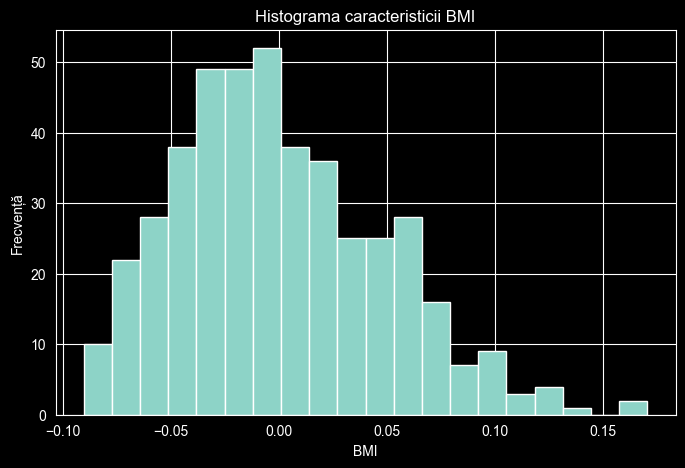

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["bmi"], bins=20)
plt.title("Histograma caracteristicii BMI")
plt.xlabel("BMI")
plt.ylabel("Frecvență")
plt.grid(True)
plt.show()

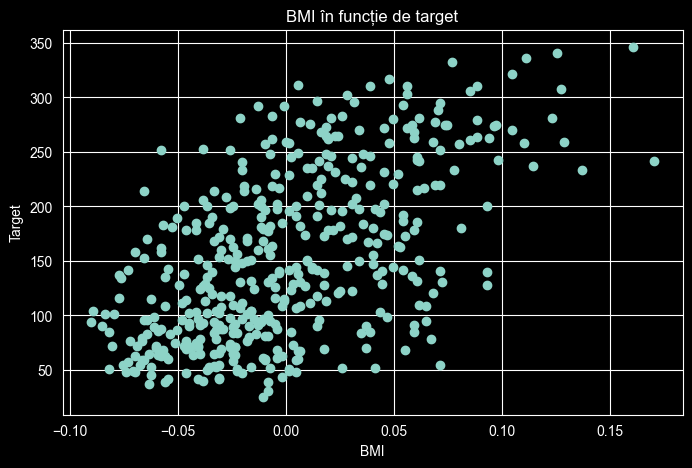

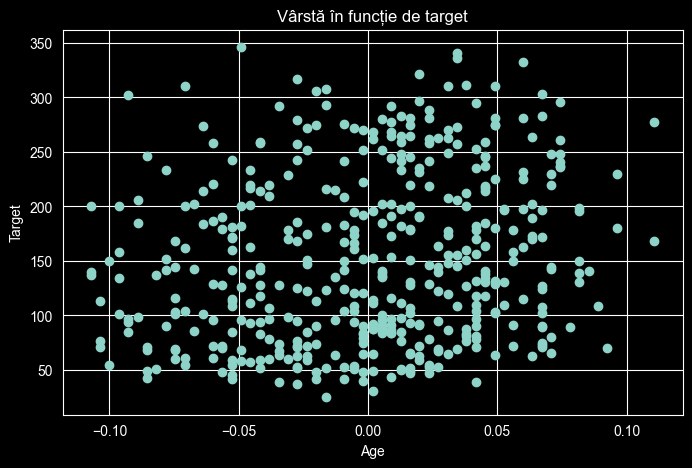

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df["bmi"], df["target"])
plt.title("BMI în funcție de target")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["age"], df["target"])
plt.title("Vârstă în funcție de target")
plt.xlabel("Age")
plt.ylabel("Target")
plt.grid(True)
plt.show()

Coeficient BMI: 998.5776891375593
Intercept: 152.00335421448167


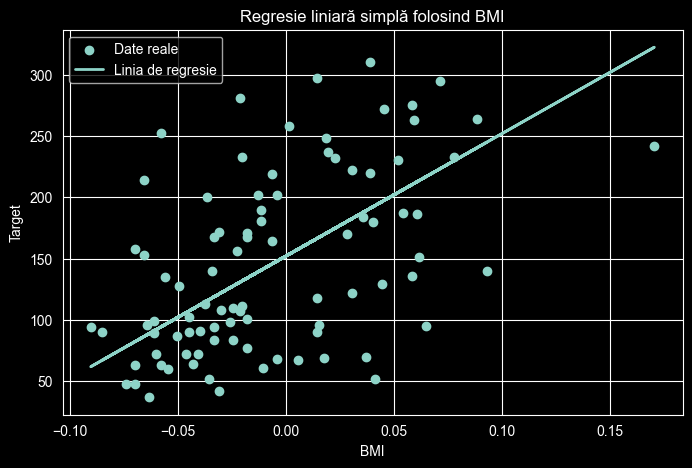

Mean Squared Error (MSE): 4061.8259284949268


In [8]:
X = df[["bmi"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred = model_simple.predict(X_test)

print("Coeficient BMI:", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label="Date reale")
plt.plot(X_test, y_pred, linewidth=2, label="Linia de regresie")
plt.title("Regresie liniară simplă folosind BMI")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.show()

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

In [9]:
X2 = df[["bmi", "bp"]]
y2 = df["target"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model_two_features = LinearRegression()
model_two_features.fit(X2_train, y2_train)

y2_pred = model_two_features.predict(X2_test)

coef_df = pd.DataFrame({
    "Caracteristică": ["bmi", "bp"],
    "Coeficient": model_two_features.coef_
})

print("Coeficienții modelului:")
print(coef_df)

r2 = r2_score(y2_test, y2_pred)
print("Scor R^2:", r2)

Coeficienții modelului:
  Caracteristică  Coeficient
0            bmi  839.519853
1             bp  393.451203
Scor R²: 0.2939977566766083
